# Wizard Quant vs Wizard Quant Offshore Comparison

This notebook compares the historical returns of Wizard Quant and Wizard Quant Offshore over their overlapping period. It also models a theoretical 2x leveraged version of the original Wizard Quant for comparison.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 6)


In [17]:
# Load data
wq = pd.read_csv('data/hf_returns/wizard_quant.csv')
wq_off = pd.read_csv('data/hf_returns/wizard_quant_offshore.csv')

# Format dates
wq['Period'] = pd.to_datetime(wq['Period'])
wq.set_index('Period', inplace=True)
wq.columns = ['Wizard Quant']

wq_off['Period'] = pd.to_datetime(wq_off['Period'])
wq_off.set_index('Period', inplace=True)
wq_off.columns = ['Wizard Quant Offshore']

# Merge to get overlapping period
df = pd.merge(wq, wq_off, left_index=True, right_index=True, how='inner')

# Create synthetic 2x leveraged version (subtracting 4% annual financing cost on the borrowed amount -> 4% / 12 per month)
financing_cost_monthly = 0.04 / 12
df['Wizard Quant (2x Leveraged)'] = df['Wizard Quant'] * 2.35 - financing_cost_monthly

df.head()


/var/folders/mc/qf75k40s6ns_nr8c35wdmp400000gn/T/ipykernel_98451/1066808426.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  wq['Period'] = pd.to_datetime(wq['Period'])


,Wizard Quant,Wizard Quant Offshore,Wizard Quant (2x Leveraged)
Period,,,
2024-07-01,0.0140,0.0030,0.029567
2024-08-01,-0.0016,0.0098,-0.007093
2024-09-01,-0.0287,-0.0140,-0.070778
2024-10-01,0.0388,0.0411,0.087847
2024-11-01,0.0313,0.0778,0.070222


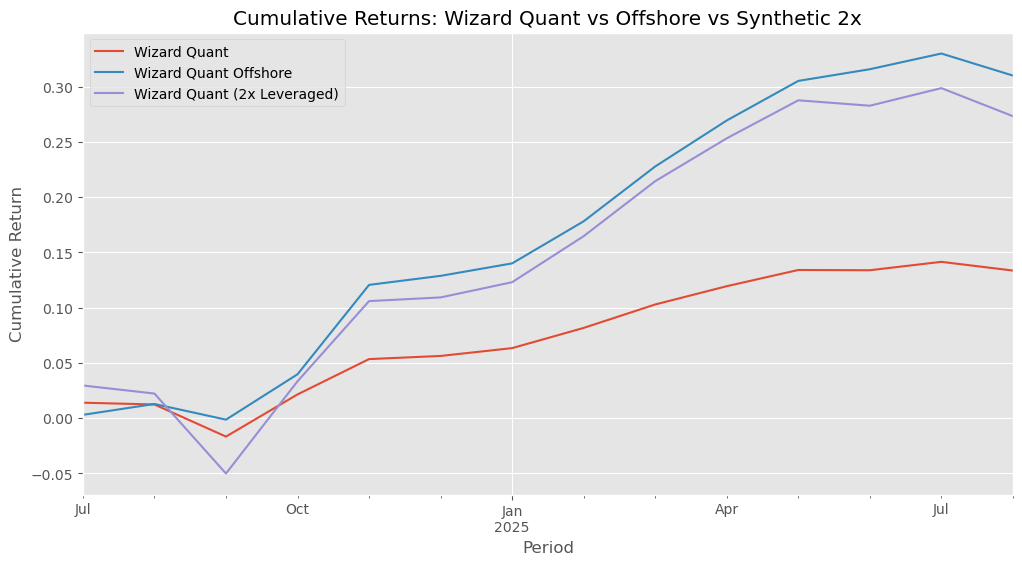

In [18]:
# Calculate cumulative returns
cum_rets = (1 + df).cumprod() - 1

# Plot
cum_rets.plot(title='Cumulative Returns: Wizard Quant vs Offshore vs Synthetic 2x')
plt.ylabel('Cumulative Return')
plt.show()


In [19]:
def calc_stats(returns):
    stats = {}
    
    # Annualized Return (CAGR)
    # Assuming monthly data
    cum_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 12
    cagr = (1 + cum_ret) ** (1 / n_years) - 1 if n_years > 0 else np.nan
    stats['CAGR'] = cagr
    
    # Annualized Volatility
    ann_vol = returns.std() * np.sqrt(12)
    stats['Ann. Volatility'] = ann_vol
    
    # Sharpe Ratio (assuming 0% risk free rate for simplicity in comparison)
    stats['Sharpe Ratio'] = (returns.mean() * 12) / ann_vol if ann_vol != 0 else np.nan
    
    # Max Drawdown
    cum_roll_max = (1 + returns).cumprod().cummax()
    drawdown = (1 + returns).cumprod() / cum_roll_max - 1
    stats['Max Drawdown'] = drawdown.min()
    
    # Mean Monthly Return
    stats['Mean Monthly Return'] = returns.mean()
    
    # Median Monthly Return
    stats['Median Monthly Return'] = returns.median()
    
    return pd.Series(stats)

# Apply to all columns
stats_df = df.apply(calc_stats)
stats_df.T


,CAGR,Ann. Volatility,Sharpe Ratio,Max Drawdown,Mean Monthly Return,Median Monthly Return
Wizard Quant,0.113440,0.057356,1.908368,-0.030254,0.009121,0.009900
Wizard Quant Offshore,0.260408,0.085800,2.762227,-0.015000,0.019750,0.010400
Wizard Quant (2x Leveraged),0.230042,0.134788,1.611605,-0.077370,0.018102,0.019932


Mean difference per month: 0.0016479761904762108
Std dev of difference: 0.022578529578773734


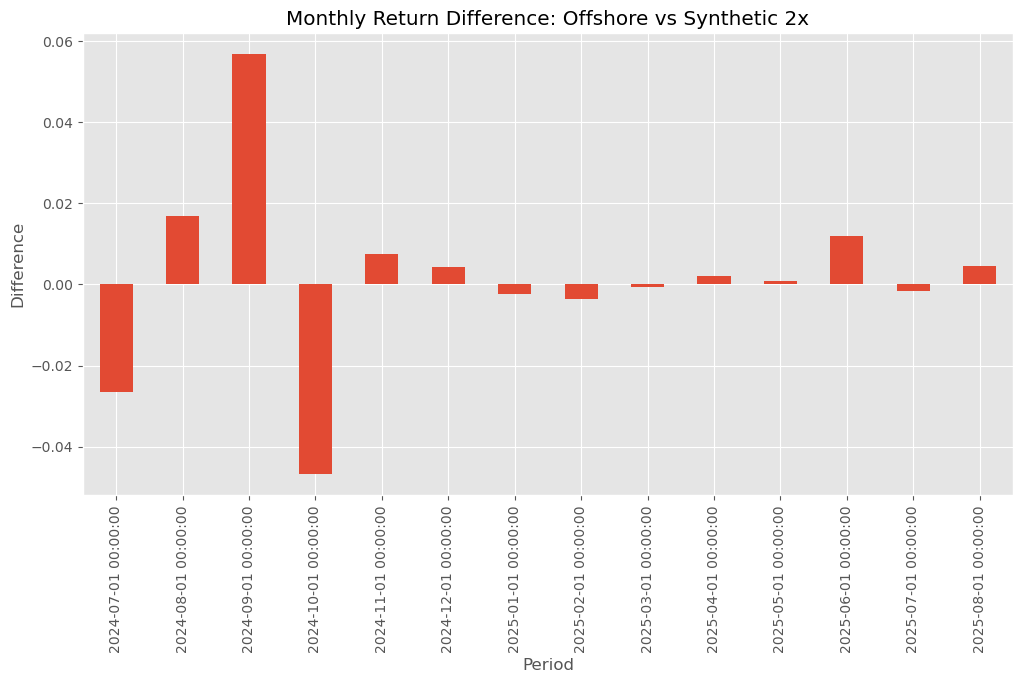

In [20]:
# Analyzing the difference between Offshore and the Synthetic 2x
df['Diff (Offshore - Synthetic 2x)'] = df['Wizard Quant Offshore'] - df['Wizard Quant (2x Leveraged)']

print("Mean difference per month:", df['Diff (Offshore - Synthetic 2x)'].mean())
print("Std dev of difference:", df['Diff (Offshore - Synthetic 2x)'].std())

df['Diff (Offshore - Synthetic 2x)'].plot(kind='bar', title='Monthly Return Difference: Offshore vs Synthetic 2x')
plt.ylabel('Difference')
plt.show()
